In [1]:
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from typing import Optional


In [2]:
@dataclass(frozen=True)
class Benchmark:
    path: str
    meta: dict
    data: Optional[pd.DataFrame]

In [3]:
def load_benchmark(path):
    meta_path = f"{path}/meta.json"

    try:
        with open(meta_path, "r") as file:
            meta = json.load(file)
    except FileNotFoundError:
        print(f"Error: '{meta_path}' file was not found.")
        return None

    csv_path = f"{path}/timing.csv"
    data = None
    try:
        data = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: '{csv_path}' file was not found.")

    return Benchmark(path, meta, data)

In [4]:
def load_benchmarks(root):
    benchmarks = []
    
    for path in root.rglob("*"):
        if path.is_file():
            if path.name == "meta.json":
                benchmark = load_benchmark(path.parent)
                if benchmark is None or benchmark.data is None:
                    print(f"Error loading benchmark '{path.parent}'.")
                else:
                    benchmarks.append(benchmark)

    return benchmarks

In [5]:
def create_benchmark_dataframe(benchmark):
    m = benchmark.meta
    df = benchmark.data.copy()
    df = df.assign(kind=m["kind"])
    df = df.assign(memory=m["memory"])                 # register = subgroups, workgroup = smem
    df = df.assign(n_keys=m["n_keys"])
    df = df.assign(n_segments=m["n_segments"])          # for avg segment size = n_keys / n_segments
    df = df.assign(variant=Path(benchmark.path).parent.name)
    df = df.assign(bin_sampler=m["bin_sampler"])

    # Each measured sample runs the phase kernels *_iterations times inside ONE
    # timed pass, so the GPU-timestamp span covers a whole batch. Divide back to
    # a single-op time. Only the sort phase is iteration-tuned in experiment 2;
    # bin/merge stay at 1 (so they sit near the ~65 us timer floor). us/ms are
    # recomputed from the corrected full-resolution ns.
    bin_it = m.get("bin_iterations", 1) or 1
    sort_it = m.get("sort_iterations", 1) or 1
    merge_it = m.get("merge_iterations", 1) or 1
    df = df.assign(bin_iterations=bin_it, sort_iterations=sort_it, merge_iterations=merge_it)
    for phase, iters in (("bin", bin_it), ("sort", sort_it), ("merge", merge_it)):
        df[f"{phase}_ns"] = df[f"{phase}_ns"] / iters
        df[f"{phase}_us"] = df[f"{phase}_ns"] / 1e3
        df[f"{phase}_ms"] = df[f"{phase}_ns"] / 1e6

    return df

def create_benchmark_meta_dataframe(benchmark):
    df = pd.json_normalize(
        benchmark.meta,
        record_path="bins",
        meta=["n_keys", "n_segments", "kind", "memory"],
        meta_prefix="run_"
    )
    df.insert(0, "bin", range(len(df)))

    return df

In [6]:
benchmarks = load_benchmarks(Path("../output/experiment2"))

In [7]:
data_dfs = [create_benchmark_dataframe(benchmark) for benchmark in benchmarks]
meta_dfs = [create_benchmark_meta_dataframe(benchmark) for benchmark in benchmarks]

data = pd.concat(data_dfs, ignore_index=True)
meta = pd.concat(meta_dfs, ignore_index=True)

In [15]:
# ===========================================================================
# PREP: every shared DataFrame, constant, and style map is computed here, once,
# from `data`. All analysis/plotting cells below read ONLY these names and
# reassign NONE of them -- so those cells can be run or reordered in any order,
# as long as this cell (and the loader above it) has run first. Each analysis
# cell still owns its plot-local temporaries (Z, tbl, g10, ...), which it always
# recomputes, so nothing leaks between them.
#
# Naming trap this avoids: the phase grid spans every N INCLUDING the N=1 no-op,
# while the throughput charts EXCLUDE it. Those two axis sets get distinct names
# (phase_seg_sizes vs seg_sizes) so neither can silently clobber the other when
# cells move around.
# ===========================================================================
import numpy as np
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm

# --- shared constants / style ------------------------------------------------
REP_SAMPLER   = "bin(3)"               # representative single bin for input-size sweeps
CEIL_MKEYS    = 400e9 / 12 / 1e6       # mem-bw ceiling: 400 GB/s at 12 B/key -> M keys/s
CEIL_GKEYS    = 400e9 / 12 / 1e9       # same, in G keys/s
GPU_VARIANTS  = ["gpu_smem", "gpu_subgroups"]
METHOD_COLORS = {"gpu_subgroups": "#e8834a", "gpu_smem": "#4269d0"}  # register=orange, workgroup=blue
METHOD_LABELS = {"gpu_subgroups": "registers", "gpu_smem": "smem"}
PHASE_COLORS  = {"bin": "#7fb3d5", "sort": "#e67e22", "merge": "#27ae60"}
PHASES        = ["bin", "sort", "merge"]
MEM_ORDER     = ["register", "workgroup"]
MEM_LABEL     = {"register": "register (subgroups)", "workgroup": "smem (workgroup)"}

# --- throughput vs KEY COUNT, at the representative bin -----------------------
rep_df = data.loc[data["bin_sampler"] == REP_SAMPLER].copy()
rep_df["wall_time_ms"] = rep_df["wall_ns"] / 1e6
rep_df["throughput_mkeys_s"] = rep_df["n_keys"] / (rep_df["sort_ns"] / 1e9) / 1e6

rep_summary = (                        # all variants, sort-phase mean/std across runs
    rep_df.groupby(["variant", "n_keys"])["throughput_mkeys_s"]
    .agg(mean="mean", std="std").reset_index().sort_values("n_keys")
)
gpu_summary = (                        # GPU variants only
    rep_df[rep_df["variant"].isin(GPU_VARIANTS)]
    .groupby(["variant", "n_keys"])["throughput_mkeys_s"]
    .agg(mean="mean", std="std").reset_index().sort_values("n_keys")
)

# --- per-op phase breakdown (bin/sort/merge, ms) vs true N, all key counts ----
# true segment size = n_keys / n_segments (NOT the bin_sampler label, which is
# one power of two too large). Keeps N=1: binning dominance there is the story.
pb = data[data["variant"].isin(GPU_VARIANTS)].copy()
pb["N"] = (pb["n_keys"] / pb["n_segments"]).round().astype(int)
pbg = (
    pb.groupby(["n_keys", "memory", "N"])[["bin_ns", "sort_ns", "merge_ns"]]
    .median().div(1e6).rename(columns=lambda c: c[:-3]).reset_index()
)
phase_key_counts = sorted(pbg["n_keys"].unique())
phase_seg_sizes  = sorted(pbg["N"].unique())           # INCLUDES N=1

# --- sort-phase throughput vs true N, all key counts (N>1) -------------------
seg = data[data["variant"].isin(GPU_VARIANTS)].copy()
seg["N"] = (seg["n_keys"] / seg["n_segments"]).round().astype(int)
seg = seg[(seg["sort_ns"] > 0) & (seg["N"] > 1)]       # drop unmeasurable ticks + N=1 no-op
seg["sort_throughput_mkeys_s"] = seg["n_keys"] / (seg["sort_ns"] / 1e9) / 1e6
sort_summary = (
    seg.groupby(["variant", "n_keys", "N"])["sort_throughput_mkeys_s"]
    .median().reset_index()
)
tp = sort_summary.pivot_table(
    index=["n_keys", "N"], columns="variant", values="sort_throughput_mkeys_s"
).reset_index()
tp["speedup"] = tp["gpu_subgroups"] / tp["gpu_smem"]   # >1 => subgroups win
key_counts = sorted(sort_summary["n_keys"].unique())
seg_sizes  = sorted(sort_summary["N"].unique())        # EXCLUDES N=1

# Segment Sort: Register vs Shared Memory



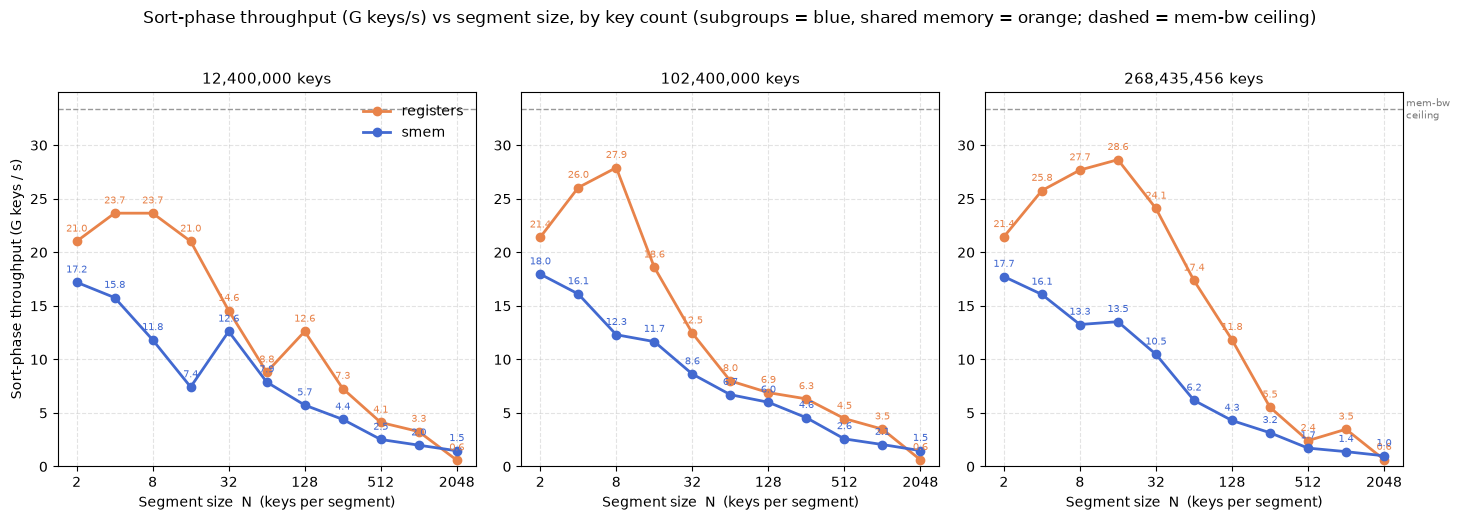

In [9]:
# ===========================================================================
# Sort-phase throughput in G keys/s vs segment size, one panel per key count
# (the three key budgets consolidated). G/s puts magnitudes on the same footing
# as bb_segsort's reg-sort figure (Hou et al. Fig 9), also in G elements/s.
# Reads sort_summary / key_counts / METHOD_* / CEIL_GKEYS / mticker from PREP;
# the largest key count (2^28) is bb_segsort's dataset size. N=1 is excluded
# upstream as a no-op.
#
# Each panel autoscales its own y. Dashed line = mem-bw ceiling (400 GB/s,
# 12 B/key). Small-mid bins can sit slightly above it even at sort_iterations=1
# (not a caching artifact -- effective traffic there is likely nearer 8 B/key);
# the N>=32 bins are unambiguously physical.
# ===========================================================================
ncols = len(key_counts)
fig, axes = plt.subplots(1, ncols, figsize=(4.9 * ncols, 5.0), sharex=True)
axes = np.atleast_1d(axes)

for ax, nk in zip(axes, key_counts):
    g_nk = sort_summary[sort_summary["n_keys"] == nk]
    for variant in ("gpu_subgroups", "gpu_smem"):
        g = g_nk[g_nk["variant"] == variant].sort_values("N")
        gkeys = g["sort_throughput_mkeys_s"] / 1e3   # M/s -> G/s
        ax.plot(g["N"], gkeys, marker="o", markersize=6, linewidth=2,
                color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
        for n, y in zip(g["N"], gkeys):
            ax.annotate(f"{y:.1f}", (n, y), textcoords="offset points",
                        xytext=(0, 7), ha="center", fontsize=7,
                        color=METHOD_COLORS[variant])
    ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1)
    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.set_title(f"{nk:,} keys", fontsize=11)
    ax.set_xlabel("Segment size  N  (keys per segment)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

axes[-1].text(axes[-1].get_xlim()[1], CEIL_GKEYS, " mem-bw\n ceiling",
              va="center", ha="left", fontsize=7, color="#777")
axes[0].set_ylabel("Sort-phase throughput (G keys / s)")
axes[0].legend(frameon=False, fontsize=10, loc="upper right")

fig.suptitle("Sort-phase throughput (G keys/s) vs segment size, by key count "
             "(subgroups = blue, shared memory = orange; dashed = mem-bw ceiling)", y=1.03)
fig.tight_layout()
plt.show()


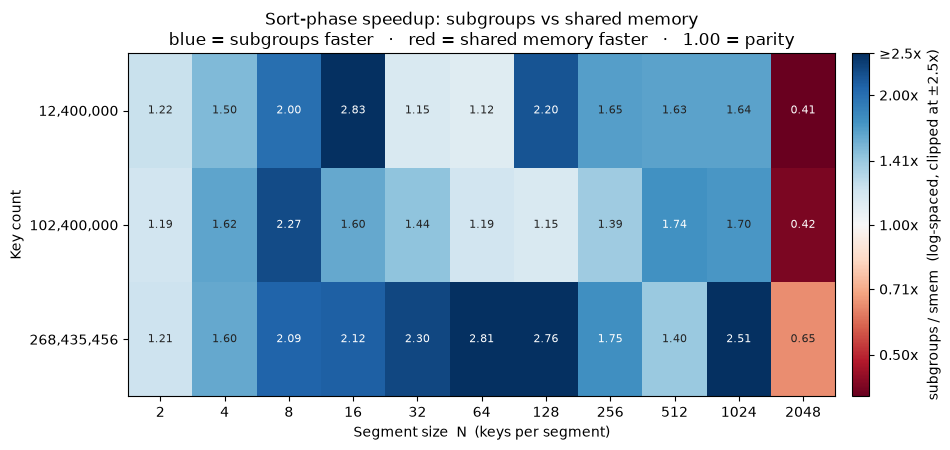

In [10]:
# ===========================================================================
# HEADLINE: where do subgroups win? Diverging heatmap of the sort-phase speedup
# (subgroup throughput / smem throughput) over segment size x key count.
# Reads tp / key_counts / seg_sizes from the PREP cell (np, mticker, TwoSlopeNorm
# also come from PREP); Z / logZ below are cell-local temporaries.
#
#   blue  = subgroups faster   red = shared memory faster   white = parity (1.0)
#
# One figure carries all four variables: N on x, key count on y, method folded
# into the ratio, throughput folded into color. Coloring is symmetric in
# log2(ratio) so a 2x win and a 2x loss are equally saturated.
#
# The color scale saturates at +/-2.5x. The largest-N register-spill corner runs
# far past that (down to ~0.07x at low key counts) -- letting it set the limit
# would flatten the whole mid-band, so those cells clip to deep red instead.
# Their true ratio is still printed in the cell, so nothing is hidden.
# ===========================================================================
Z = (
    tp.pivot(index="n_keys", columns="N", values="speedup")
    .reindex(index=key_counts, columns=seg_sizes)
)
logZ = np.log2(Z.values)
lim = float(np.log2(2.5))                              # saturate beyond +/-2.5x
norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")

# Annotate each cell with the raw ratio; white ink on saturated cells.
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        r = Z.values[i, j]
        if np.isnan(r):
            continue
        ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=8, color=ink)

ax.set_xticks(range(len(seg_sizes)))
ax.set_xticklabels([f"{n}" for n in seg_sizes])
ax.set_yticks(range(len(key_counts)))
ax.set_yticklabels([f"{n:,}" for n in key_counts])
ax.set_xlabel("Segment size  N  (keys per segment)")
ax.set_ylabel("Key count")
ax.set_title("Sort-phase speedup: subgroups vs shared memory\n"
             "blue = subgroups faster   ·   red = shared memory faster   ·   1.00 = parity")

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_ticks(np.log2([0.5, 0.71, 1.0, 1.41, 2.0, 2.5]))
cbar.ax.set_yticklabels(["0.50x", "0.71x", "1.00x", "1.41x", "2.00x", "≥2.5x"])
cbar.set_label("subgroups / smem  (log-spaced, clipped at ±2.5x)")

fig.tight_layout()
plt.show()

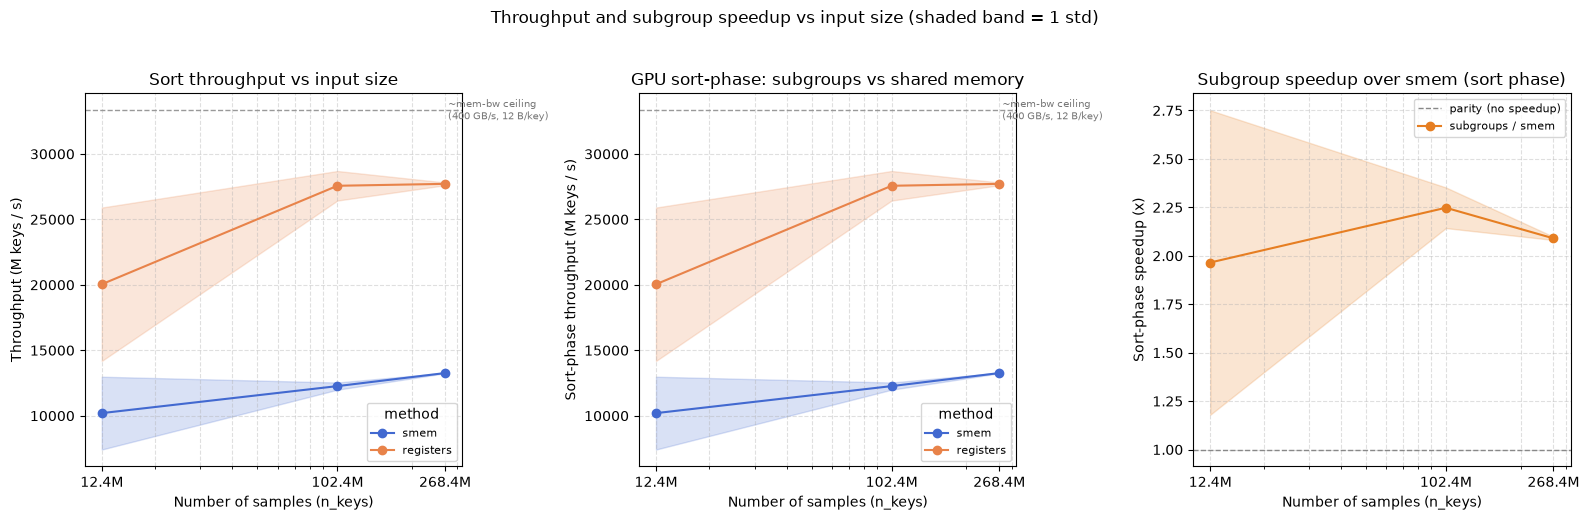

In [11]:
# ===========================================================================
# Throughput / speedup vs INPUT SIZE (n_keys) at the representative bin, three
# views in one figure. All frames come from the PREP cell (rep_summary,
# gpu_summary, CEIL_MKEYS); pivot_* below are cell-local temporaries.
#   [0] GPU variants (subgroups vs smem), sort throughput (M keys/s)
#   [1] GPU subgroups vs smem, sort-phase throughput (M keys/s)
#   [2] subgroups / smem speedup, with propagated 1-std band
# Shaded bands are +/-1 std across runs; x is log (input spans ~4 decades).
# The dashed line in [0]/[1] is the mem-bw ceiling (400 GB/s, 12 B/key); where a
# curve pokes above it the GPU timestamp is under-counting, not real bandwidth.
# register (subgroups) = orange, workgroup (smem) = blue, per METHOD_COLORS.
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# [0] sort throughput, GPU variants only (gpu_adaptive excluded)
ax = axes[0]
for variant, g in rep_summary[rep_summary["variant"].isin(GPU_VARIANTS)].groupby("variant"):
    ax.plot(g["n_keys"], g["mean"], marker="o",
            color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
    ax.fill_between(g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
                    color=METHOD_COLORS[variant], alpha=0.2)
ax.axhline(CEIL_MKEYS, color="#999", linestyle="--", linewidth=1)
ax.text(rep_summary["n_keys"].max(), CEIL_MKEYS, " ~mem-bw ceiling\n (400 GB/s, 12 B/key)",
        va="center", ha="left", fontsize=7, color="#777")
ax.set_ylabel("Throughput (M keys / s)")
ax.set_title("Sort throughput vs input size")
ax.legend(title="method", fontsize=8)

# [1] GPU subgroups vs smem, sort-phase throughput
ax = axes[1]
for variant, g in gpu_summary.groupby("variant"):
    ax.plot(g["n_keys"], g["mean"], marker="o",
            color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
    ax.fill_between(g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
                    color=METHOD_COLORS[variant], alpha=0.2)
ax.axhline(CEIL_MKEYS, color="#999", linestyle="--", linewidth=1)
ax.text(gpu_summary["n_keys"].max(), CEIL_MKEYS, " ~mem-bw ceiling\n (400 GB/s, 12 B/key)",
        va="center", ha="left", fontsize=7, color="#777")
ax.set_ylabel("Sort-phase throughput (M keys / s)")
ax.set_title("GPU sort-phase: subgroups vs shared memory")
ax.legend(title="method", fontsize=8)

# [2] subgroups / smem speedup, propagated 1-std band
ax = axes[2]
pivot_mean = gpu_summary.pivot(index="n_keys", columns="variant", values="mean")
pivot_std = gpu_summary.pivot(index="n_keys", columns="variant", values="std")
ratio = pivot_mean["gpu_subgroups"] / pivot_mean["gpu_smem"]
# Propagate uncertainty for r = a/b:  sigma_r/r = sqrt((sa/a)^2 + (sb/b)^2)
rel_err = (
    (pivot_std["gpu_subgroups"] / pivot_mean["gpu_subgroups"]) ** 2
    + (pivot_std["gpu_smem"] / pivot_mean["gpu_smem"]) ** 2
) ** 0.5
ratio_err = ratio * rel_err
ax.axhline(1.0, color="#888", linestyle="--", linewidth=1, label="parity (no speedup)")
ax.plot(ratio.index, ratio.values, marker="o", color="#e67e22", label="subgroups / smem")
ax.fill_between(ratio.index, (ratio - ratio_err).values, (ratio + ratio_err).values,
                color="#e67e22", alpha=0.2)
ax.set_ylabel("Sort-phase speedup (x)")
ax.set_title("Subgroup speedup over smem (sort phase)")
ax.legend(fontsize=8)

# Tick only at the actual key counts and label them compactly, so the log axis
# stops crowding minor-tick labels on top of each other.
xticks = sorted(rep_summary["n_keys"].unique())
for ax in axes:
    ax.set_xscale("log")   # input size spans ~4 decades
    ax.set_xlabel("Number of samples (n_keys)")
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.4g}M"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

fig.suptitle("Throughput and subgroup speedup vs input size (shaded band = 1 std)", y=1.03)
fig.tight_layout()
plt.show()


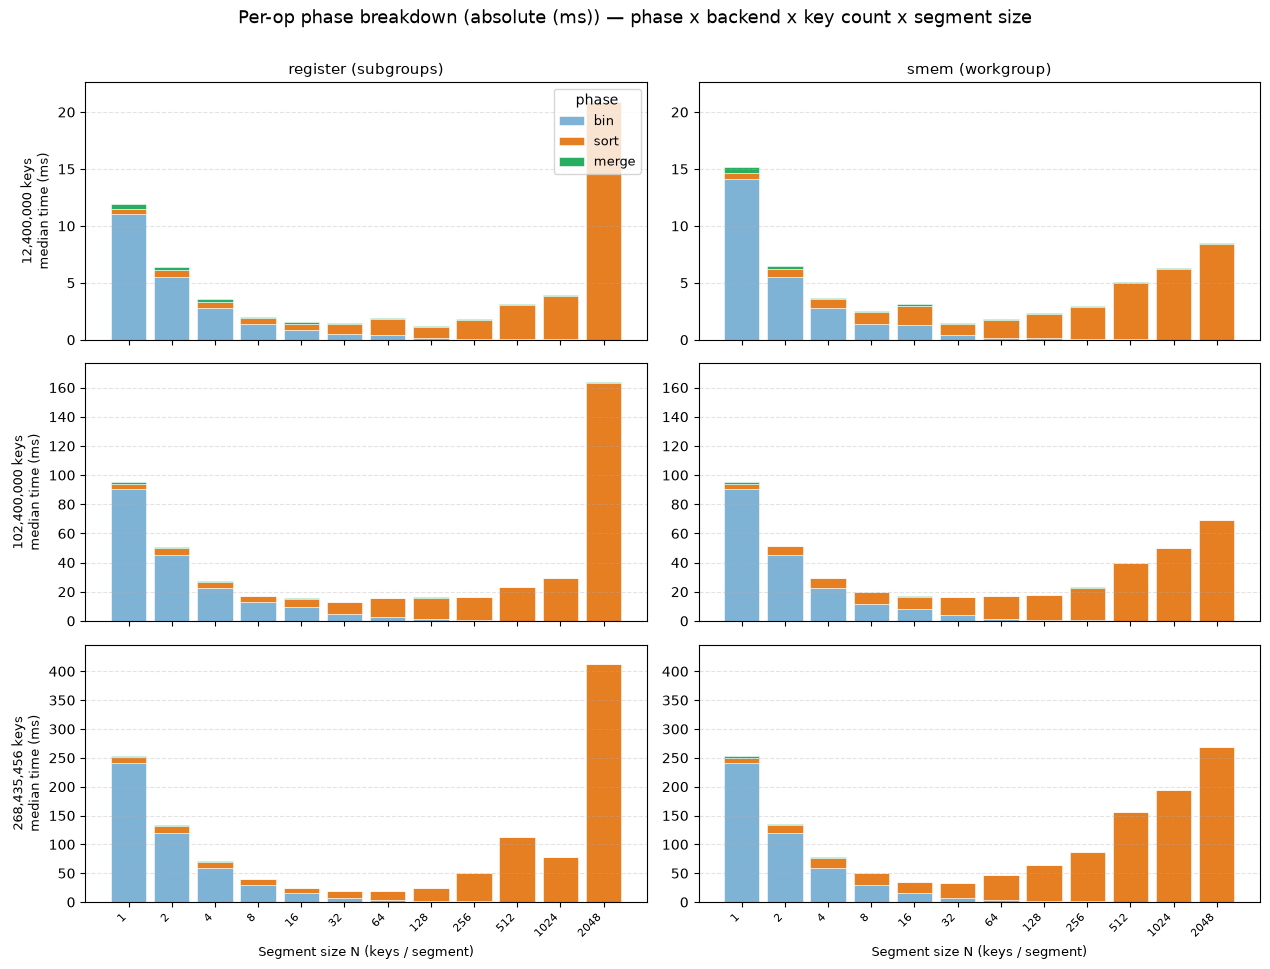

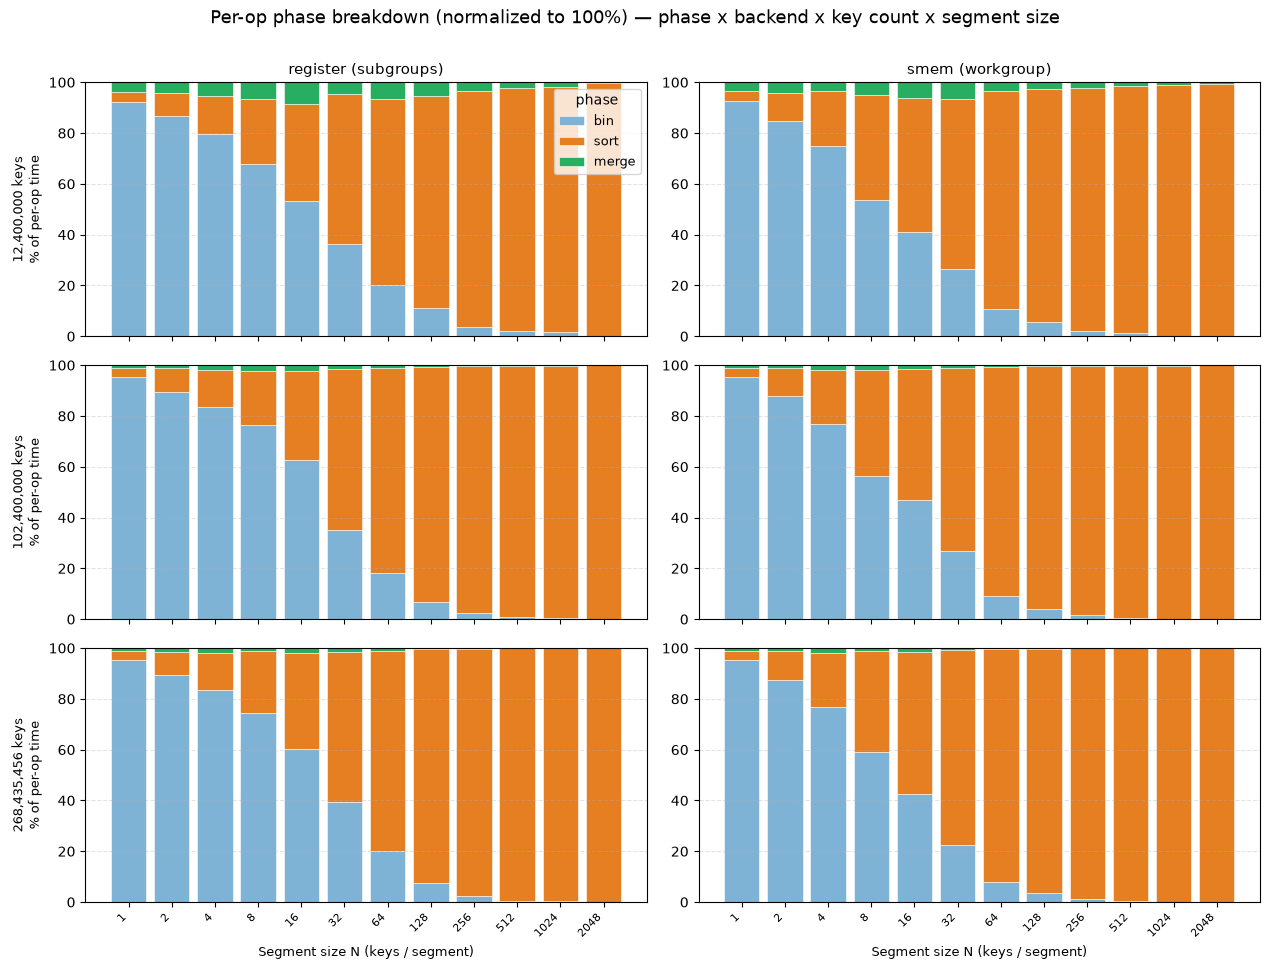

In [12]:
# ===========================================================================
# PHASE BREAKDOWN across all four dimensions at once: phase (bin/sort/merge) x
# memory backend (register = subgroups, workgroup = smem) x key count x segment
# size. Small-multiple STACKED BARS -- rows = key count, columns = backend,
# x within a panel = segment size, each bar stacked by phase.
#
# Two figures:
#   (A) absolute median per-op time (ms). y is shared across the two backends in
#       each row so smem vs register are directly comparable; it grows ~10x per
#       key-count decade, so rows stay independent.
#   (B) the same, normalized to 100%, so the phase MIX is legible regardless of
#       magnitude -- this is the one that shows binning eating the small-N budget.
#
# pbg / phase_key_counts / phase_seg_sizes (true segment size, INCLUDING the N=1
# no-op) and the PHASE_* / MEM_* style maps all come from the PREP cell.
# ===========================================================================
def draw_phase_grid(normalize):
    xpos = np.arange(len(phase_seg_sizes))
    nrows, ncols = len(phase_key_counts), len(MEM_ORDER)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6.4 * ncols, 3.2 * nrows), sharex=True, squeeze=False
    )
    for r, nk in enumerate(phase_key_counts):
        # shared y per row (absolute view only)
        row_top = 0.0
        for mem in MEM_ORDER:
            s = pbg[(pbg["n_keys"] == nk) & (pbg["memory"] == mem)]
            if not s.empty:
                row_top = max(row_top, s[PHASES].sum(axis=1).max())
        for c, mem in enumerate(MEM_ORDER):
            ax = axes[r][c]
            s = (
                pbg[(pbg["n_keys"] == nk) & (pbg["memory"] == mem)]
                .set_index("N").reindex(phase_seg_sizes)
            )
            vals = {p: s[p].fillna(0).values for p in PHASES}
            if normalize:
                tot = np.sum([vals[p] for p in PHASES], axis=0)
                tot[tot == 0] = 1.0
                vals = {p: 100.0 * vals[p] / tot for p in PHASES}
            bottom = np.zeros(len(phase_seg_sizes))
            for p in PHASES:
                ax.bar(
                    xpos, vals[p], bottom=bottom, width=0.82,
                    color=PHASE_COLORS[p], edgecolor="white", linewidth=0.4,
                    label=p if (r == 0 and c == 0) else None,
                )
                bottom += vals[p]
            ax.set_xticks(xpos)
            ax.set_xticklabels(phase_seg_sizes, rotation=45, ha="right", fontsize=8)
            ax.set_ylim(0, 100 if normalize else (row_top * 1.08 if row_top else 1))
            if r == 0:
                ax.set_title(MEM_LABEL[mem], fontsize=11)
            if c == 0:
                unit = "% of per-op time" if normalize else "median time (ms)"
                ax.set_ylabel(f"{nk:,} keys\n{unit}", fontsize=9)
            if r == nrows - 1:
                ax.set_xlabel("Segment size N (keys / segment)", fontsize=9)
            ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    axes[0][0].legend(title="phase", loc="upper right", fontsize=9)
    kind = "normalized to 100%" if normalize else "absolute (ms)"
    fig.suptitle(
        f"Per-op phase breakdown ({kind}) — phase x backend x key count x segment size",
        y=1.005, fontsize=13,
    )
    fig.tight_layout()
    return fig


draw_phase_grid(normalize=False)
draw_phase_grid(normalize=True)
plt.show()


In [13]:
# Sanity peek at the prepared per-(variant, key count, true N) sort-phase table
# that the heatmap / small-multiples / summary table below all draw from. The
# actual computation lives in the PREP cell near the top (sort_summary, tp,
# key_counts, seg_sizes) -- this cell only displays it, so it can sit anywhere.
print(f"sort_summary: {len(sort_summary)} rows | key counts {key_counts} | N {seg_sizes}")
tp.head()


sort_summary: 66 rows | key counts [np.int64(12400000), np.int64(102400000), np.int64(268435456)] | N [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]


variant,n_keys,N,gpu_smem,gpu_subgroups,speedup
0,12400000,2,17200.816761,21023.220486,1.222222
1,12400000,4,15767.415365,23651.123047,1.500000
2,12400000,8,11825.561523,23651.123047,2.000000
3,12400000,16,7422.814002,21023.220486,2.832244
4,12400000,32,12613.932292,14554.537260,1.153846


In [14]:
# ===========================================================================
# TABLE: median sort-phase throughput (M keys/s) for every bin x memory x key
# count. Rows are the segment-size bin (N = 2**bin); columns pair each key count
# with the two sort backends (subgroups = register, smem = workgroup). Draws
# from sort_summary (per-cell medians) computed in the prep cell above.
#
# Also written tidy to output/experiment2/throughput_summary.csv for reuse
# (e.g. a normalized comparison against bb_segsort).
# ===========================================================================
tbl = sort_summary.copy()
tbl["bin"] = np.log2(tbl["N"]).round().astype(int)          # k such that N = 2**k
tbl["method"] = tbl["variant"].map({"gpu_subgroups": "subgroups", "gpu_smem": "smem"})

# Tidy long form -> CSV (full precision, one row per bin/method/key count).
tidy = (
    tbl[["bin", "N", "method", "n_keys", "sort_throughput_mkeys_s"]]
    .rename(columns={"sort_throughput_mkeys_s": "throughput_mkeys_s"})
    .sort_values(["bin", "method", "n_keys"])
    .reset_index(drop=True)
)
csv_path = Path("../output/experiment2/throughput_summary.csv")
tidy.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(tidy)} rows)")

# Wide, human-readable grid: bin/N x (key count, method).
wide = (
    tbl.pivot_table(
        index=["bin", "N"],
        columns=["n_keys", "method"],
        values="sort_throughput_mkeys_s",
    )
    .round(1)
    .sort_index()
)
wide.columns.names = ["n_keys", "method"]
print("\nMedian sort-phase throughput (M keys/s):")
wide

wrote ../output/experiment2/throughput_summary.csv  (66 rows)

Median sort-phase throughput (M keys/s):


n_keys   12400000            102400000           268435456          
method        smem subgroups      smem subgroups      smem subgroups
bin N                                                               
1   2      17200.8   21023.2   17959.8   21404.1   17731.6   21445.0
2   4      15767.4   23651.1   16108.2   26041.7   16062.7   25761.0
3   8      11825.6   23651.1   12303.1   27901.8   13255.7   27675.7
4   16      7422.8   21023.2   11660.4   18601.2   13518.2   28643.4
5   32     12613.9   14554.5    8632.6   12452.0   10475.7   24094.1
6   64      7883.7    8805.2    6706.0    7992.8    6178.0   17371.2
7   128     5733.6   12613.9    5998.1    6898.5    4295.8   11838.2
8   256     4400.2    7277.3    4555.4    6313.2    3152.0    5531.4
9   512     2522.8    4113.2    2578.4    4477.1    1719.2    2413.0
10  1024    1991.7    3262.2    2050.5    3487.7    1387.1    3478.6
11  2048    1466.7     594.1    1481.0     626.8     998.3     649.7